In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def parse_log_file(file_path):
    """Parses BasicSR/SwinIR training logs into DataFrames."""

    # Regex patterns
    # Matches: [epoch:  4, iter:  16,100, lr:(1.000e-04,)] ... l_pix: ...
    train_pattern = re.compile(
        r'epoch:\s*(\d+),\s*iter:\s*([\d,]+),\s*lr:\(([\d\.e-]+),\).*?'
        r'l_pix:\s*([\d\.e-]+).*?l_kd_t1:\s*([\d\.e-]+).*?l_kd_t2:\s*([\d\.e-]+).*?l_kd:\s*([\d\.e-]+)'
    )

    # Matches: Validation Set5
    val_dataset_pattern = re.compile(r'INFO: Validation\s+(\w+)')
    # Matches: # psnr: 36.1338
    val_metric_pattern = re.compile(r'\s+#\s+(psnr|ssim):\s*([\d\.]+)')

    train_data = []
    val_data = []

    current_iter = 0
    current_val_dataset = None
    current_val_metrics = {}

    with open(file_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        # --- Parse Training Lines ---
        train_match = train_pattern.search(line)
        if train_match:
            epoch, iter_str, lr, l_pix, l_kd_t1, l_kd_t2, l_kd = train_match.groups()
            current_iter = int(iter_str.replace(',', ''))

            train_data.append({
                'epoch': int(epoch),
                'iteration': current_iter,
                'lr': float(lr),
                'l_pix': float(l_pix),
                'l_kd_t1': float(l_kd_t1),
                'l_kd_t2': float(l_kd_t2),
                'l_kd': float(l_kd)
            })
            continue

        # --- Parse Validation Lines ---
        # Detect start of a validation block for a specific dataset
        val_dataset_match = val_dataset_pattern.search(line)
        if val_dataset_match:
            current_val_dataset = val_dataset_match.group(1)
            current_val_metrics = {'dataset': current_val_dataset, 'iteration': current_iter}
            continue

        # Extract PSNR/SSIM
        if current_val_dataset:
            metric_match = val_metric_pattern.search(line)
            if metric_match:
                metric_name, value = metric_match.groups()
                current_val_metrics[metric_name] = float(value)

                # Once we have both PSNR and SSIM, push to list and reset
                if 'psnr' in current_val_metrics and 'ssim' in current_val_metrics:
                    val_data.append(current_val_metrics)
                    current_val_dataset = None # Reset for next dataset

    return pd.DataFrame(train_data), pd.DataFrame(val_data)


# --- Execution ---
log_file = ['message (1).txt', 'message (2).txt', 'message (3).txt'] # Ensure this matches your filename
train_data = []
val_data = []
for log in log_file:
    df_train, df_val = parse_log_file(log)
    train_data.append(df_train)
    val_data.append(df_val)

# Concatenate all DataFrames
train_data = pd.concat(train_data, ignore_index=True)
val_data = pd.concat(val_data, ignore_index=True)

# Save to CSV for external use
train_data.to_csv('training_results.csv', index=False)
val_data.to_csv('validation_results.csv', index=False)

print(f"Parsed {len(train_data)} training records and {len(val_data)} validation records.")
print(train_data.head())

    # Plot


Parsed 264 training records and 88 validation records.
   epoch  iteration      lr     l_pix   l_kd_t1   l_kd_t2      l_kd
0      4      16100  0.0001  0.101180  0.014607  0.014863  0.014735
1      4      16200  0.0001  0.123700  0.017476  0.017818  0.017647
2      4      16300  0.0001  0.085968  0.011419  0.011684  0.011552
3      4      16400  0.0001  0.083336  0.010913  0.011178  0.011045
4      4      16500  0.0001  0.078764  0.010385  0.010432  0.010409


In [10]:
train = pd.read_csv('training_results.csv').sort_values('iteration').reset_index(drop=True)
val = pd.read_csv('validation_results.csv').sort_values('iteration').reset_index(drop=True)


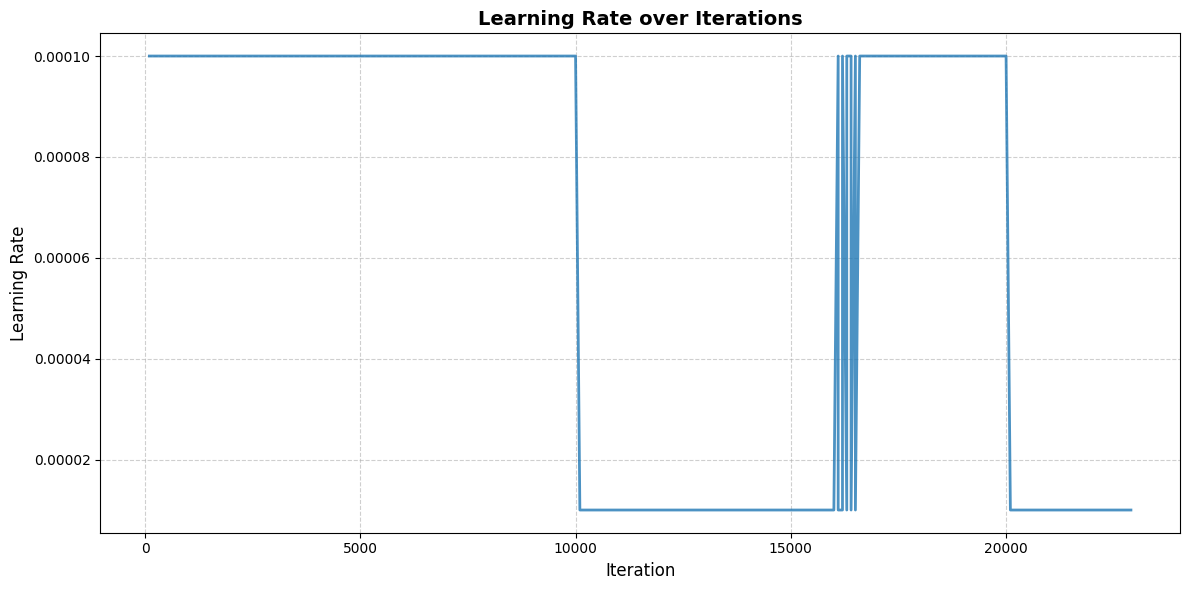

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(train['iteration'], train['lr'], linewidth=2, alpha=0.8)

plt.title('Learning Rate over Iterations', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



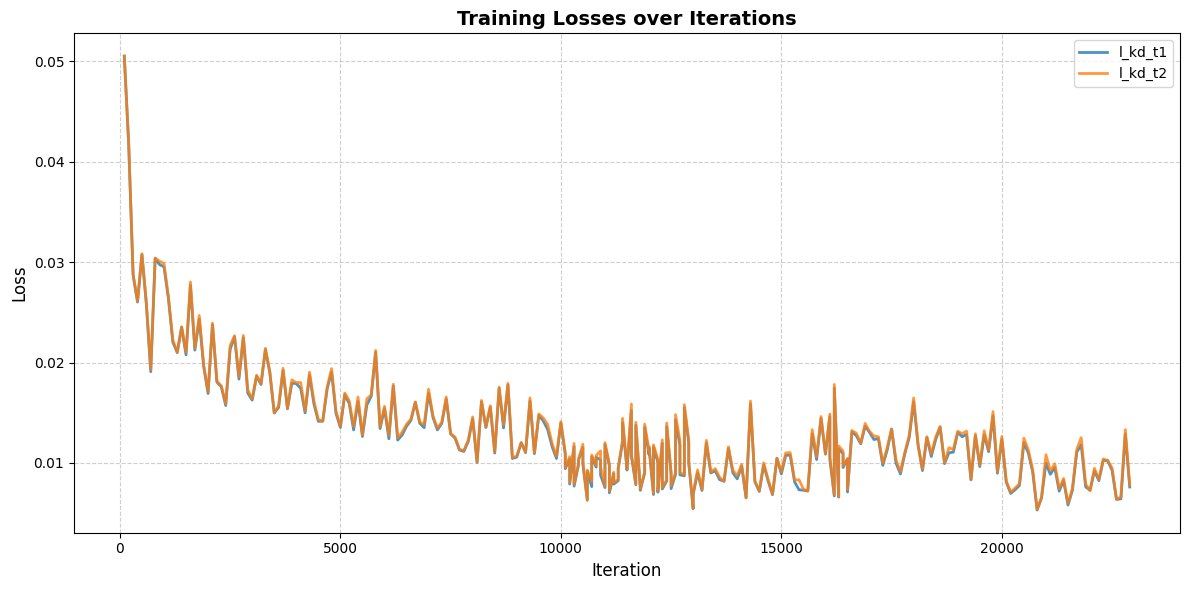

In [ ]:
loss_cols = [ 'l_kd_t1', 'l_kd_t2']
plt.figure(figsize=(12, 6))

for col in loss_cols:
    plt.plot(train['iteration'], train[col], label=col, linewidth=2, alpha=0.8, lab)

plt.title('Training Losses over Iterations', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

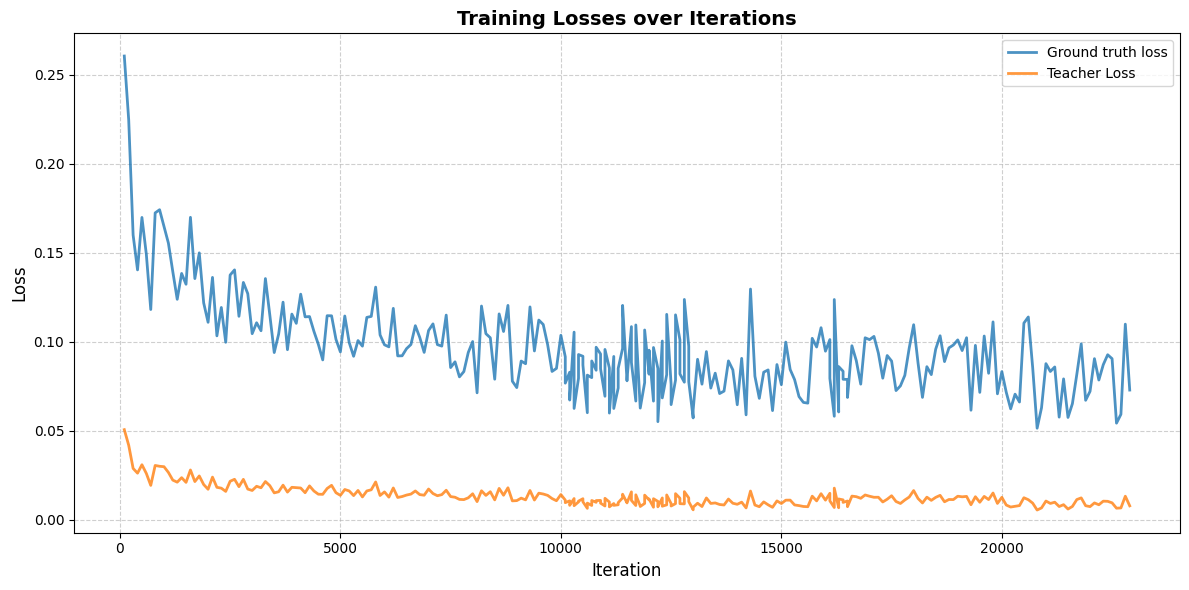

In [25]:
from cProfile import label


loss_cols = ['l_pix','l_kd']
plt.figure(figsize=(12, 6))

plt.plot(train['iteration'], train["l_pix"], linewidth=2, alpha=0.8, label="Ground truth loss")

plt.plot(train['iteration'], train["l_kd"], label="Teacher Loss", linewidth=2, alpha=0.8)


plt.title('Training Losses over Iterations', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
val.head()

,dataset,iteration,psnr,ssim
0,Set5,1000,20.0467,0.7623
1,Urban100,1000,12.6934,0.2760
2,BSDS100,1000,21.3321,0.7185
3,Set14,1000,20.9608,0.7281
4,Urban100,2000,11.9076,0.2438


In [ ]:
result_cols = ['psnr']
plt.figure(figsize=(12, 6))
i=0
for col in result_cols:
    plt.plot(val['iteration'], val[col], label=val['dataset'], linewidth=2, alpha=0.8)
    i+=1.5

plt.title('Training Losses over Iterations', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

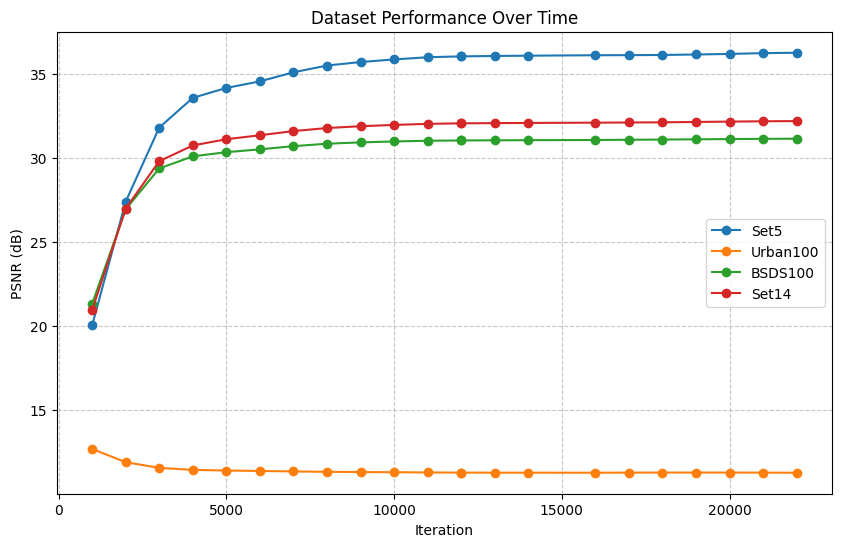

In [22]:
# Plotting
plt.figure(figsize=(10, 6))

# Loop through each dataset and plot a line
for name in val['dataset'].unique():
    subset = val[val['dataset'] == name]
    plt.plot(subset['iteration'], subset['psnr'], marker='o', label=name)

plt.title("Dataset Performance Over Time")
plt.xlabel("Iteration")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

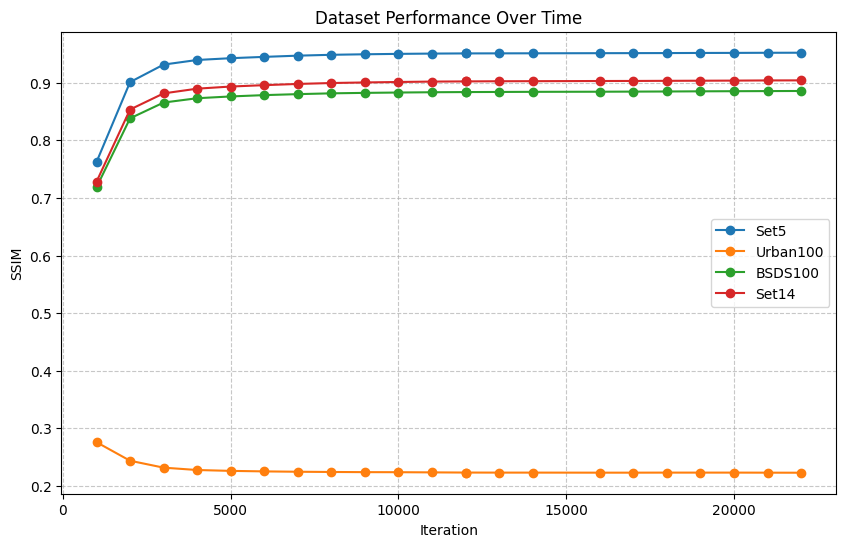

In [23]:
# Plotting
plt.figure(figsize=(10, 6))

# Loop through each dataset and plot a line
for name in val['dataset'].unique():
    subset = val[val['dataset'] == name]
    plt.plot(subset['iteration'], subset['ssim'], marker='o', label=name)

plt.title("Dataset Performance Over Time")
plt.xlabel("Iteration")
plt.ylabel("SSIM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()